<a href="https://colab.research.google.com/github/ranjetmahato416/-Lung-CT-Image-Classification-Using-Public-Medical-Imaging-Data-/blob/main/Desktop/Colab_Notebook/Notebook/Notebook_15_Final_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 15 — Final Evaluation and Dissertation Figures

This notebook consolidates the results of the complete lung nodule malignancy classification study.

Three ImageNet-pretrained CNN architectures were investigated:

1. EfficientNetB0
2. DenseNet121
3. ResNet50

Each architecture was trained and fine-tuned using identical patient-level data splits. Model configuration selection was performed using validation PR-AUC, and the selected configuration for each architecture was subsequently evaluated on the untouched test set.

The objectives of this notebook are to:

- compare the final performance of all architectures;
- quantify the effect of fine-tuning;
- summarize the operating characteristics of the selected EfficientNetB0 model;
- generate publication-quality tables and figures;
- consolidate Grad-CAM explainability results;
- create a final results package for the dissertation.

##1. Imports

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

##2. Mount Drive

In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


##3. Define paths

In [3]:
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Dissertation"
)

MODEL_ROOT = PROJECT_ROOT / "Models"

EFFICIENTNET_ROOT = (
    MODEL_ROOT
    / "EfficientNetB0_FineTune_Last30"
)

DENSENET_ROOT = (
    MODEL_ROOT
    / "DenseNet121"
    / "Corrected_Run_01"
)

RESNET_ROOT = (
    MODEL_ROOT
    / "ResNet50"
    / "Corrected_Run_01"
)

COMPARISON_ROOT = (
    MODEL_ROOT
    / "Model_Comparison"
)

GRADCAM_ROOT = (
    COMPARISON_ROOT
    / "GradCAM_DenseNet121"
)

FINAL_RESULTS_ROOT = (
    COMPARISON_ROOT
    / "Final_Dissertation_Results"
)

FIGURE_DIR = (
    FINAL_RESULTS_ROOT
    / "Figures"
)

TABLE_DIR = (
    FINAL_RESULTS_ROOT
    / "Tables"
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

##4. Load final model summaries

In [4]:
efficientnet_summary = pd.read_csv(
    EFFICIENTNET_ROOT
    / "model_summary.csv"
)

densenet_summary = pd.read_csv(
    DENSENET_ROOT
    / "Results"
    / "densenet121_experiment_summary.csv"
)

resnet_summary = pd.read_csv(
    RESNET_ROOT
    / "Results"
    / "resnet50_experiment_summary.csv"
)

display(efficientnet_summary)
display(densenet_summary)
display(resnet_summary)

,SelectedModel,ValidationROC_AUC,ValidationPR_AUC,TestROC_AUC,TestPR_AUC,DefaultThreshold,ValidationF1Threshold,HighRecallThreshold
0,Fine-Tuned EfficientNetB0,0.850649,0.570277,0.830252,0.633736,0.5,0.464395,0.327528


,Selected Model,Baseline Validation ROC-AUC,Baseline Validation PR-AUC,Fine-Tuned Validation ROC-AUC,Fine-Tuned Validation PR-AUC,Validation F1 Threshold,Validation High-Recall Threshold,Test ROC-AUC,Test PR-AUC
0,Fine-Tuned DenseNet121,0.814935,0.489087,0.861586,0.587677,0.669041,0.445648,0.855333,0.588136


,Selected Model,Baseline Validation ROC-AUC,Baseline Validation PR-AUC,Baseline Validation F1,Fine-Tuned Validation ROC-AUC,Fine-Tuned Validation PR-AUC,Fine-Tuned Validation F1,Selected Validation F1 Threshold,Selected High-Recall Threshold,Test ROC-AUC,Test PR-AUC
0,Fine-Tuned ResNet50,0.797847,0.467531,0.478261,0.797163,0.497598,0.489796,0.600719,0.113742,0.822883,0.562283


##5. Load architecture selection

In [5]:
with open(
    COMPARISON_ROOT
    / "final_model_selection.json",
    "r"
) as file:

    final_selection = json.load(file)

print(
    json.dumps(
        final_selection,
        indent=4
    )
)

{
    "FinalArchitecture": "DenseNet121",
    "SelectedConfiguration": "Fine-Tuned DenseNet121",
    "PrimarySelectionMetric": "Validation PR-AUC",
    "ValidationROCAUC": 0.8615857826384143,
    "ValidationPRAUC": 0.5876770576684937,
    "TestROCAUC": 0.855332902391726,
    "TestPRAUC": 0.5881362975400494
}


In [6]:
assert (
    final_selection[
        "FinalArchitecture"
    ]
    == "DenseNet121"
)

assert (
    final_selection[
        "PrimarySelectionMetric"
    ]
    == "Validation PR-AUC"
)

print(
    "Final architecture confirmed:",
    final_selection[
        "FinalArchitecture"
    ]
)

print(
    "Selection metric confirmed:",
    final_selection[
        "PrimarySelectionMetric"
    ]
)

Final architecture confirmed: DenseNet121
Selection metric confirmed: Validation PR-AUC


##6. Build final three-model comparison

In [7]:
final_model_comparison = pd.DataFrame(
    [
        {
            "Architecture":
                "EfficientNetB0",

            "Selected Configuration":
                efficientnet_summary.loc[
                    0,
                    "SelectedModel"
                ],

            "Validation ROC-AUC":
                efficientnet_summary.loc[
                    0,
                    "ValidationROC_AUC"
                ],

            "Validation PR-AUC":
                efficientnet_summary.loc[
                    0,
                    "ValidationPR_AUC"
                ],

            "Test ROC-AUC":
                efficientnet_summary.loc[
                    0,
                    "TestROC_AUC"
                ],

            "Test PR-AUC":
                efficientnet_summary.loc[
                    0,
                    "TestPR_AUC"
                ]
        },

        {
            "Architecture":
                "DenseNet121",

            "Selected Configuration":
                densenet_summary.loc[
                    0,
                    "Selected Model"
                ],

            "Validation ROC-AUC":
                densenet_summary.loc[
                    0,
                    "Fine-Tuned Validation ROC-AUC"
                ],

            "Validation PR-AUC":
                densenet_summary.loc[
                    0,
                    "Fine-Tuned Validation PR-AUC"
                ],

            "Test ROC-AUC":
                densenet_summary.loc[
                    0,
                    "Test ROC-AUC"
                ],

            "Test PR-AUC":
                densenet_summary.loc[
                    0,
                    "Test PR-AUC"
                ]
        },

        {
            "Architecture":
                "ResNet50",

            "Selected Configuration":
                resnet_summary.loc[
                    0,
                    "Selected Model"
                ],

            "Validation ROC-AUC":
                resnet_summary.loc[
                    0,
                    "Fine-Tuned Validation ROC-AUC"
                ],

            "Validation PR-AUC":
                resnet_summary.loc[
                    0,
                    "Fine-Tuned Validation PR-AUC"
                ],

            "Test ROC-AUC":
                resnet_summary.loc[
                    0,
                    "Test ROC-AUC"
                ],

            "Test PR-AUC":
                resnet_summary.loc[
                    0,
                    "Test PR-AUC"
                ]
        }
    ]
)

display(
    final_model_comparison
)

,Architecture,Selected Configuration,Validation ROC-AUC,Validation PR-AUC,Test ROC-AUC,Test PR-AUC
0,EfficientNetB0,Fine-Tuned EfficientNetB0,0.850649,0.570277,0.830252,0.633736
1,DenseNet121,Fine-Tuned DenseNet121,0.861586,0.587677,0.855333,0.588136
2,ResNet50,Fine-Tuned ResNet50,0.797163,0.497598,0.822883,0.562283


##7. Add Ranking

In [8]:
final_model_comparison[
    "Test PR-AUC Rank"
] = (
    final_model_comparison[
        "Test PR-AUC"
    ]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)

final_model_comparison[
    "Test ROC-AUC Rank"
] = (
    final_model_comparison[
        "Test ROC-AUC"
    ]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)

display(
    final_model_comparison
)

,Architecture,Selected Configuration,Validation ROC-AUC,Validation PR-AUC,Test ROC-AUC,Test PR-AUC,Test PR-AUC Rank,Test ROC-AUC Rank
0,EfficientNetB0,Fine-Tuned EfficientNetB0,0.850649,0.570277,0.830252,0.633736,1,2
1,DenseNet121,Fine-Tuned DenseNet121,0.861586,0.587677,0.855333,0.588136,2,1
2,ResNet50,Fine-Tuned ResNet50,0.797163,0.497598,0.822883,0.562283,3,3


In [9]:
final_model_comparison[
    "Validation PR-AUC Rank"
] = (
    final_model_comparison[
        "Validation PR-AUC"
    ]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)

In [10]:
final_model_comparison[
    "Validation PR-AUC Rank"
] = (
    final_model_comparison[
        "Validation PR-AUC"
    ]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)

##8.Save final architecture table

In [11]:
FINAL_MODEL_TABLE_PATH = (
    TABLE_DIR
    / "final_model_comparison.csv"
)

final_model_comparison.to_csv(
    FINAL_MODEL_TABLE_PATH,
    index=False
)

print(
    "Saved:",
    FINAL_MODEL_TABLE_PATH
)

Saved: /content/drive/MyDrive/Dissertation/Models/Model_Comparison/Final_Dissertation_Results/Tables/final_model_comparison.csv


##9. Fine-tuning improvement table

In [37]:
fine_tuning_comparison = pd.DataFrame(
    [
        {
            "Architecture":
                "DenseNet121",

            "Baseline ROC-AUC":
                densenet_summary.loc[
                    0,
                    "Baseline Validation ROC-AUC"
                ],

            "Fine-Tuned ROC-AUC":
                densenet_summary.loc[
                    0,
                    "Fine-Tuned Validation ROC-AUC"
                ],

            "Baseline PR-AUC":
                densenet_summary.loc[
                    0,
                    "Baseline Validation PR-AUC"
                ],

            "Fine-Tuned PR-AUC":
                densenet_summary.loc[
                    0,
                    "Fine-Tuned Validation PR-AUC"
                ]
        },

        {
            "Architecture":
                "ResNet50",

            "Baseline ROC-AUC":
                resnet_summary.loc[
                    0,
                    "Baseline Validation ROC-AUC"
                ],

            "Fine-Tuned ROC-AUC":
                resnet_summary.loc[
                    0,
                    "Fine-Tuned Validation ROC-AUC"
                ],

            "Baseline PR-AUC":
                resnet_summary.loc[
                    0,
                    "Baseline Validation PR-AUC"
                ],

            "Fine-Tuned PR-AUC":
                resnet_summary.loc[
                    0,
                    "Fine-Tuned Validation PR-AUC"
                ]
        }
    ]
)

In [38]:
# Calculate Changes #

fine_tuning_comparison[
    "ROC-AUC Improvement"
] = (
    fine_tuning_comparison[
        "Fine-Tuned ROC-AUC"
    ]
    -
    fine_tuning_comparison[
        "Baseline ROC-AUC"
    ]
)

fine_tuning_comparison[
    "PR-AUC Improvement"
] = (
    fine_tuning_comparison[
        "Fine-Tuned PR-AUC"
    ]
    -
    fine_tuning_comparison[
        "Baseline PR-AUC"
    ]
)

display(
    fine_tuning_comparison
)

,Architecture,Baseline ROC-AUC,Fine-Tuned ROC-AUC,Baseline PR-AUC,Fine-Tuned PR-AUC,ROC-AUC Improvement,PR-AUC Improvement
0,DenseNet121,0.814935,0.861586,0.489087,0.587677,0.046651,0.098590
1,ResNet50,0.797847,0.797163,0.467531,0.497598,-0.000684,0.030068


##10. Load final EfficientNet test predictions

In [14]:
DENSENET_TEST_PREDICTIONS_PATH = (
    GRADCAM_ROOT
    / "densenet121_test_predictions.csv"
)

densenet_test_predictions = (
    pd.read_csv(
        DENSENET_TEST_PREDICTIONS_PATH
    )
)

display(
    densenet_test_predictions.head()
)

print(
    "Samples:",
    len(
        densenet_test_predictions
    )
)

,PatientID,NoduleID,CancerLabel,LabelName,ImagePath,ResolvedImagePath,ImageExists,PredictedProbability,PredictedLabel,Outcome
0,LIDC-IDRI-0014,1,0,Benign,/content/drive/MyDrive/Dissertation/Dataset/Pr...,/content/drive/MyDrive/Dissertation/Dataset/Pr...,True,0.070976,0,TN
1,LIDC-IDRI-0018,1,0,Benign,/content/drive/MyDrive/Dissertation/Dataset/Pr...,/content/drive/MyDrive/Dissertation/Dataset/Pr...,True,0.251632,0,TN
2,LIDC-IDRI-0018,2,0,Benign,/content/drive/MyDrive/Dissertation/Dataset/Pr...,/content/drive/MyDrive/Dissertation/Dataset/Pr...,True,0.147418,0,TN
3,LIDC-IDRI-0018,3,0,Benign,/content/drive/MyDrive/Dissertation/Dataset/Pr...,/content/drive/MyDrive/Dissertation/Dataset/Pr...,True,0.130756,0,TN
4,LIDC-IDRI-0018,4,1,Malignant,/content/drive/MyDrive/Dissertation/Dataset/Pr...,/content/drive/MyDrive/Dissertation/Dataset/Pr...,True,0.867159,1,TP


Samples: 256


In [15]:
y_true = (
    densenet_test_predictions[
        "CancerLabel"
    ]
    .astype(int)
    .values
)

y_prob = (
    densenet_test_predictions[
        "PredictedProbability"
    ]
    .values
)

In [16]:
verified_roc_auc = roc_auc_score(
    y_true,
    y_prob
)

verified_pr_auc = average_precision_score(
    y_true,
    y_prob
)

print(
    "Verified DenseNet121 test ROC-AUC:",
    verified_roc_auc
)

print(
    "Verified DenseNet121 test PR-AUC:",
    verified_pr_auc
)

Verified DenseNet121 test ROC-AUC: 0.855332902391726
Verified DenseNet121 test PR-AUC: 0.5881362975400494


In [17]:
expected_roc_auc = float(
    densenet_summary.loc[
        0,
        "Test ROC-AUC"
    ]
)

expected_pr_auc = float(
    densenet_summary.loc[
        0,
        "Test PR-AUC"
    ]
)

assert np.isclose(
    verified_roc_auc,
    expected_roc_auc,
    atol=1e-4
)

assert np.isclose(
    verified_pr_auc,
    expected_pr_auc,
    atol=1e-4
)

print(
    "✓ Final DenseNet121 metrics reproduced."
)

✓ Final DenseNet121 metrics reproduced.


##11. Load final thresholds

In [18]:
DEFAULT_THRESHOLD = 0.5

F1_THRESHOLD = float(
    densenet_summary.loc[
        0,
        "Validation F1 Threshold"
    ]
)

HIGH_RECALL_THRESHOLD = float(
    densenet_summary.loc[
        0,
        "Validation High-Recall Threshold"
    ]
)

print(
    "Default threshold:",
    DEFAULT_THRESHOLD
)

print(
    "Validation F1 threshold:",
    F1_THRESHOLD
)

print(
    "High-recall threshold:",
    HIGH_RECALL_THRESHOLD
)

Default threshold: 0.5
Validation F1 threshold: 0.6690409183502197
High-recall threshold: 0.4456476867198944


##12. Calculate final threshold metrics

In [19]:
def calculate_threshold_metrics(
    y_true,
    y_prob,
    threshold,
    threshold_name
):

    y_pred = (
        y_prob >= threshold
    ).astype(int)

    tn, fp, fn, tp = (
        confusion_matrix(
            y_true,
            y_pred
        )
        .ravel()
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0
    )

    return {
        "Operating Point":
            threshold_name,

        "Threshold":
            threshold,

        "Accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "Precision":
            precision_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "Sensitivity":
            recall_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "Specificity":
            specificity,

        "F1":
            f1_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp)
    }

In [20]:
densenet_threshold_results = pd.DataFrame(
    [
        calculate_threshold_metrics(
            y_true,
            y_prob,
            DEFAULT_THRESHOLD,
            "Default 0.50"
        ),

        calculate_threshold_metrics(
            y_true,
            y_prob,
            F1_THRESHOLD,
            "Validation F1"
        ),

        calculate_threshold_metrics(
            y_true,
            y_prob,
            HIGH_RECALL_THRESHOLD,
            "High Recall"
        )
    ]
)

display(
    densenet_threshold_results
)

,Operating Point,Threshold,Accuracy,Precision,Sensitivity,Specificity,F1,TN,FP,FN,TP
0,Default 0.50,0.500000,0.867188,0.512821,0.571429,0.914027,0.540541,202,19,15,20
1,Validation F1,0.669041,0.894531,0.681818,0.428571,0.968326,0.526316,214,7,20,15
2,High Recall,0.445648,0.871094,0.523810,0.628571,0.909502,0.571429,201,20,13,22


In [21]:
# Save #

densenet_threshold_results.to_csv(
    TABLE_DIR
    / "densenet_final_threshold_comparison.csv",
    index=False
)

##13. Final EfficientNet confusion matrix

In [22]:
final_y_pred = (
    y_prob >= F1_THRESHOLD
).astype(int)

final_cm = confusion_matrix(
    y_true,
    final_y_pred
)

print(
    final_cm
)

[[214   7]
 [ 20  15]]


####Plot

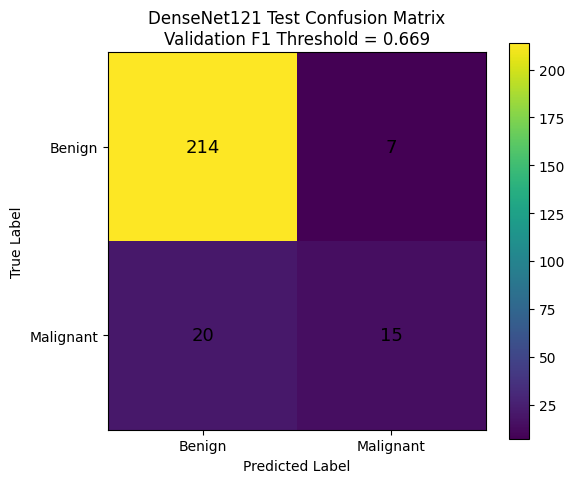

In [23]:
plt.figure(
    figsize=(6, 5)
)

plt.imshow(
    final_cm
)

plt.colorbar()

class_names = [
    "Benign",
    "Malignant"
]

plt.xticks(
    [0, 1],
    class_names
)

plt.yticks(
    [0, 1],
    class_names
)

for i in range(2):
    for j in range(2):

        plt.text(
            j,
            i,
            str(
                final_cm[i, j]
            ),
            ha="center",
            va="center",
            fontsize=13
        )

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "True Label"
)

plt.title(
    "DenseNet121 Test Confusion Matrix\n"
    f"Validation F1 Threshold = {F1_THRESHOLD:.3f}"
)

plt.tight_layout()

CONFUSION_MATRIX_PATH = (
    FIGURE_DIR
    / "densenet121_final_confusion_matrix.png"
)

plt.savefig(
    CONFUSION_MATRIX_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

##14. Final EfficientNet ROC curve

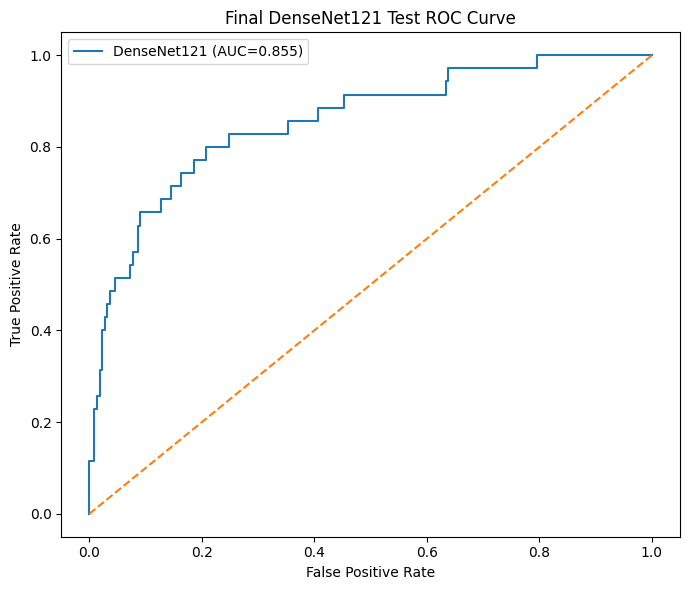

In [24]:
fpr, tpr, _ = roc_curve(
    y_true,
    y_prob
)

plt.figure(
    figsize=(7, 6)
)

plt.plot(
    fpr,
    tpr,
    label=(
    f"DenseNet121 "
    f"(AUC={verified_roc_auc:.3f})"
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "Final DenseNet121 Test ROC Curve"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURE_DIR
    / "densenet121_test_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

##15. Final precision-recall curve

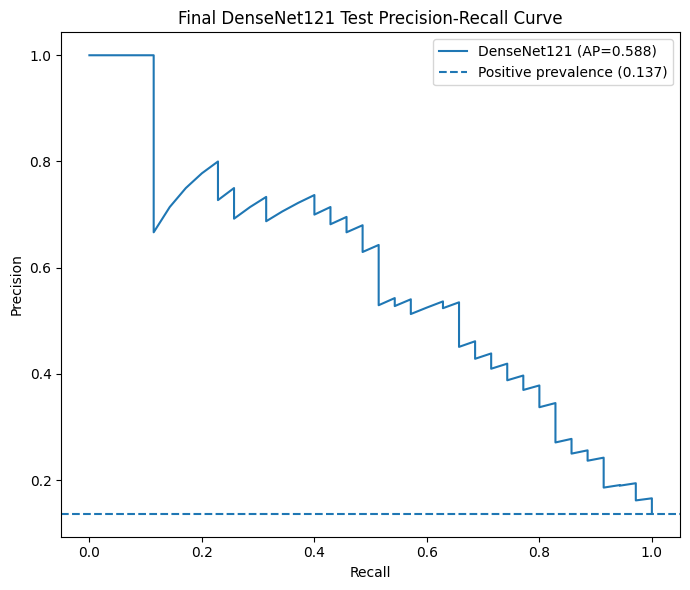

In [25]:
precision_values, \
recall_values, \
_ = precision_recall_curve(
    y_true,
    y_prob
)

positive_prevalence = (
    y_true.mean()
)

plt.figure(
    figsize=(7, 6)
)

plt.plot(
    recall_values,
    precision_values,
    label=(
        f"DenseNet121 "
        f"(AP={verified_pr_auc:.3f})"
    )
)

plt.axhline(
    positive_prevalence,
    linestyle="--",
    label=(
        f"Positive prevalence "
        f"({positive_prevalence:.3f})"
    )
)

plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Final DenseNet121 Test Precision-Recall Curve"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURE_DIR
    / "densenet121_test_pr_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

##16. Three-model metric comparison chart

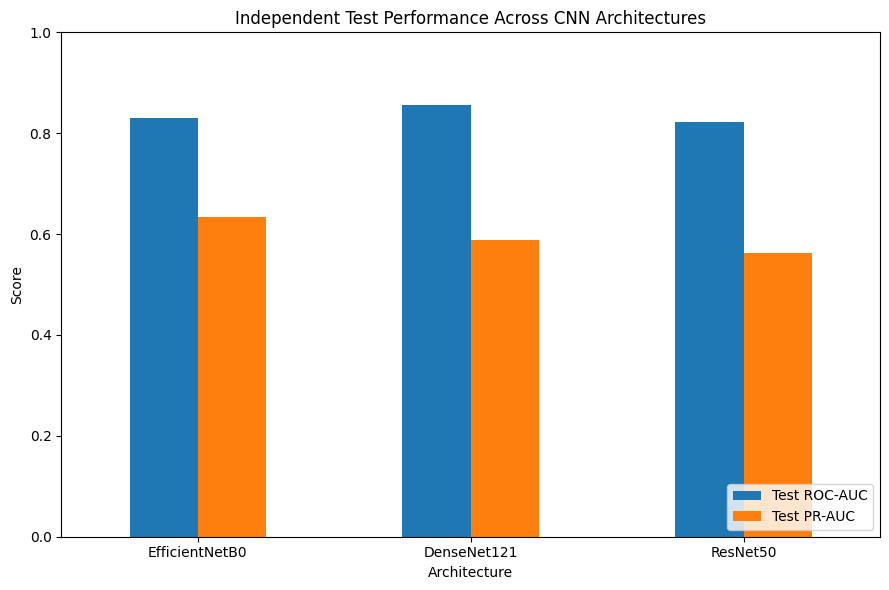

In [26]:
plot_df = (
    final_model_comparison[
        [
            "Architecture",
            "Test ROC-AUC",
            "Test PR-AUC"
        ]
    ]
    .set_index(
        "Architecture"
    )
)

ax = plot_df.plot(
    kind="bar",
    figsize=(9, 6)
)

plt.ylabel(
    "Score"
)

plt.ylim(
    0,
    1
)

plt.title(
    "Independent Test Performance Across CNN Architectures"
)

plt.xticks(
    rotation=0
)

plt.legend(
    loc="lower right"
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR
    / "cnn_architecture_test_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

##17. Threshold trade-off chart

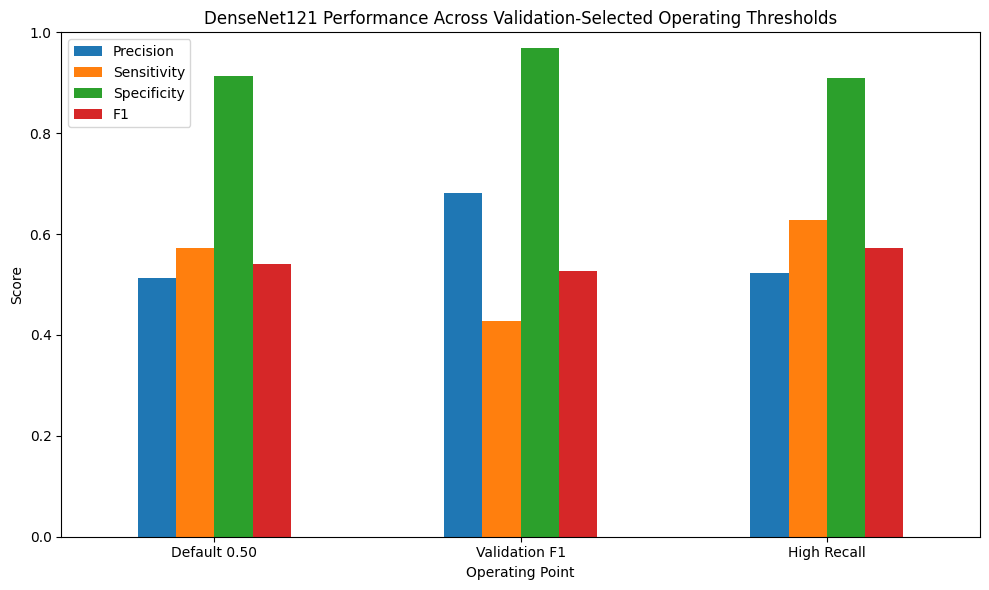

In [27]:
threshold_plot_df = (
    densenet_threshold_results[
        [
            "Operating Point",
            "Precision",
            "Sensitivity",
            "Specificity",
            "F1"
        ]
    ]
    .set_index(
        "Operating Point"
    )
)

threshold_plot_df.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.ylabel(
    "Score"
)

plt.ylim(
    0,
    1
)

plt.title(
    "DenseNet121 Performance Across Validation-Selected Operating Thresholds"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR
    / "densenet121_threshold_tradeoffs.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

##18. Load Grad-CAM summary

In [41]:
gradcam_summary = pd.read_csv(
    GRADCAM_ROOT
    / "gradcam_outcome_summary.csv"
)

display(
    gradcam_summary
)

,Outcome,Count
0,TN,214
1,FN,20
2,TP,15
3,FP,7


##19. Create master results summary

In [42]:
# ============================================================
# Load Final Grad-CAM Configuration
# ============================================================

with open(
    GRADCAM_ROOT
    / "gradcam_configuration.json",
    "r"
) as file:

    gradcam_config = json.load(file)

print(
    json.dumps(
        gradcam_config,
        indent=4
    )
)

{
    "Architecture": "DenseNet121",
    "Checkpoint": "/content/drive/MyDrive/Dissertation/Models/DenseNet121/Corrected_Run_01/FineTune_Last30/best_model.keras",
    "ArchitectureSelectionMetric": "Validation PR-AUC",
    "ValidationPRAUC": 0.5876770576684937,
    "TestROCAUC": 0.855332902391726,
    "TestPRAUC": 0.5881362975400494,
    "DecisionThreshold": 0.6690409183502197,
    "DecisionThresholdSource": "Validation F1 optimisation",
    "HighRecallThreshold": 0.4456476867198944,
    "GradCAMLayer": "conv5_block16_2_conv",
    "GradCAMFeatureShape": [
        4,
        4
    ],
    "GradCAMTarget": "Predicted class"
}


In [43]:
master_results = {

    "SelectedArchitecture":
        "DenseNet121",

    "SelectedConfiguration":
        "Fine-Tuned DenseNet121",

    "ArchitectureSelectionMetric":
        "Validation PR-AUC",

    "ValidationROC_AUC":
        float(
            densenet_summary.loc[
                0,
                "Fine-Tuned Validation ROC-AUC"
            ]
        ),

    "ValidationPR_AUC":
        float(
            densenet_summary.loc[
                0,
                "Fine-Tuned Validation PR-AUC"
            ]
        ),

    "TestROC_AUC":
        float(
            verified_roc_auc
        ),

    "TestPR_AUC":
        float(
            verified_pr_auc
        ),

    "ValidationF1Threshold":
        float(
            F1_THRESHOLD
        ),

    "HighRecallThreshold":
        float(
            HIGH_RECALL_THRESHOLD
        ),

    "TestSamples":
        int(
            len(
                y_true
            )
        ),

    "TestBenign":
        int(
            np.sum(
                y_true == 0
            )
        ),

    "TestMalignant":
        int(
            np.sum(
                y_true == 1
            )
        ),

    "GradCAMArchitecture":
    gradcam_config[
        "Architecture"
    ],

    "GradCAMLayer":
        gradcam_config[
            "GradCAMLayer"
        ],

    "GradCAMFeatureShape":
        gradcam_config[
            "GradCAMFeatureShape"
        ]
}

In [44]:
with open(
    FINAL_RESULTS_ROOT
    / "master_results.json",
    "w"
) as file:

    json.dump(
        master_results,
        file,
        indent=4
    )

print(
    json.dumps(
        master_results,
        indent=4
    )
)

{
    "SelectedArchitecture": "DenseNet121",
    "SelectedConfiguration": "Fine-Tuned DenseNet121",
    "ArchitectureSelectionMetric": "Validation PR-AUC",
    "ValidationROC_AUC": 0.8615857826384143,
    "ValidationPR_AUC": 0.5876770576684937,
    "TestROC_AUC": 0.855332902391726,
    "TestPR_AUC": 0.5881362975400494,
    "ValidationF1Threshold": 0.6690409183502197,
    "HighRecallThreshold": 0.4456476867198944,
    "TestSamples": 256,
    "TestBenign": 221,
    "TestMalignant": 35,
    "GradCAMArchitecture": "DenseNet121",
    "GradCAMLayer": "conv5_block16_2_conv",
    "GradCAMFeatureShape": [
        4,
        4
    ]
}
